# Guide to load dataset for inference


## LeRobot Format

* This tutorial will show how to load data in LeRobot Format by using our dataloader. 
* We will use the `robot_sim.PickNPlace` dataset as an example which is already converted to LeRobot Format. 
* To understand how to convert your own dataset, please refer to [Gr00t's LeRobot.md](LeRobot_compatible_data_schema.md)

In [1]:
from gr00t.utils.misc import any_describe
from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.data.dataset import ModalityConfig
from gr00t.data.schema import EmbodimentTag

/home/breeze/anaconda3/envs/gr00t/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/breeze/anaconda3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Loading the dataset

We need to define 3 things to load the dataset:
1. Path to the dataset

2. `ModalityConfigs`

- `ModalityConfigs` defines what data modalities (like video, state, actions, language) to use downstream like model training or inference.
- Each modality specifies which frame to load via delta_indices (e.g. [0] means current frame only, [-1,0] means previous and current frame)

3. `EmbodimentTag`
- `EmbodimentTag` is used to specify the embodiment of the dataset. A list of all the embodiment tags can be found in `gr00t.data.embodiment_tags.EmbodimentTag`.
- GR00T's architecture has different action heads optimized for specific robot types (embodiments). `EmbodimentTag` tells the model which action head to use for fine-tuning and/or inference. In our case, since we're using a humanoid arm, we specify `EmbodimentTag.GR1_UNIFIED` to get the best performance from the humanoid-specific action head.


In [2]:

import os
import gr00t

# REPO_PATH is the path of the pip install gr00t repo and one level up
REPO_PATH = os.path.dirname(os.path.dirname(gr00t.__file__))
DATA_PATH = "/home/breeze/Desktop/workplace/Isaac-GR00T/demo_data/piper_test"

print("Loading dataset... from", DATA_PATH)

Loading dataset... from /home/breeze/Desktop/workplace/Isaac-GR00T/demo_data/piper_test


In [3]:
# 2. modality configs
modality_configs = {
    "video": ModalityConfig(
        delta_indices=[0],
        modality_keys=["video.cam_1"],  # 从 modality.json 映射来的新 key
    ),
    "state": ModalityConfig(
        delta_indices=[0],
        modality_keys=[
            "state.single_arm",
            "state.gripper"
        ],
    ),
    "action": ModalityConfig(
        delta_indices=[0],
        modality_keys=[
            "action.single_arm",
            "action.gripper"
        ],
    ),
    "language": ModalityConfig(
        delta_indices=[0],
        modality_keys=["annotation.human.task_description"],
    ),
}

In [5]:
from gr00t.data.dataset import ModalityConfig
from gr00t.experiment.data_config import DATA_CONFIG_MAP
import pprint
# get the data config
data_config = DATA_CONFIG_MAP["agilex_piper"]

# get the modality configs and transforms
modality_configs = data_config.modality_config()
pp = pprint.PrettyPrinter(indent=2, compact=False)
print("Modality configs:")
pp.pprint(modality_configs)

dataset = LeRobotSingleDataset(
    dataset_path="/home/breeze/Desktop/workplace/Isaac-GR00T/demo_data/piper_test",
    modality_configs=modality_configs,
    transforms=None,  # we can choose to not apply any transforms
    embodiment_tag=EmbodimentTag.GR1, # the embodiment to use
    video_backend="torchvision_av"
)

dataset[7]

Modality configs:
{ 'action': ModalityConfig(delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], modality_keys=['action.single_arm', 'action.gripper']),
  'language': ModalityConfig(delta_indices=[0], modality_keys=['annotation.human.task_description']),
  'state': ModalityConfig(delta_indices=[0], modality_keys=['state.single_arm', 'state.gripper']),
  'video': ModalityConfig(delta_indices=[0], modality_keys=['video.cam_1'])}
Initialized dataset piper_test with EmbodimentTag.GR1


{'video.cam_1': array([[[[  7,  36,  24],
          [  7,  36,  24],
          [  7,  36,  24],
          ...,
          [ 73, 136, 123],
          [ 72, 135, 122],
          [ 71, 134, 121]],
 
         [[  7,  36,  24],
          [  7,  36,  24],
          [  7,  36,  24],
          ...,
          [ 73, 136, 123],
          [ 72, 135, 122],
          [ 72, 135, 122]],
 
         [[  7,  36,  24],
          [  7,  36,  24],
          [  7,  36,  24],
          ...,
          [ 73, 138, 124],
          [ 73, 136, 123],
          [ 73, 136, 123]],
 
         ...,
 
         [[125, 216, 183],
          [119, 210, 177],
          [112, 203, 170],
          ...,
          [ 83, 104, 102],
          [ 81, 102, 100],
          [ 80, 101,  99]],
 
         [[126, 217, 184],
          [120, 211, 178],
          [113, 204, 171],
          ...,
          [ 82, 103, 101],
          [ 83, 101, 100],
          [ 82, 100,  99]],
 
         [[126, 217, 184],
          [120, 211, 178],
          [113,

In [7]:
# 3. gr00t embodiment tag
embodiment_tag = EmbodimentTag.NEW_EMBODIMENT

# load the dataset
dataset = LeRobotSingleDataset(
    dataset_path="/home/breeze/Desktop/workplace/Isaac-GR00T/demo_data/piper_test",
    modality_configs=modality_configs,
    transforms=None,  # we can choose to not apply any transforms
    embodiment_tag=EmbodimentTag.GR1, # the embodiment to use
    video_backend="torchvision_av"
)

print('\n'*2)
print("="*100)
print(f"{' Humanoid Dataset ':=^100}")
print("="*100)
print("Dataset length:", len(dataset))
print("Modality keys:", dataset.modality_keys)
# print the 7th data point
resp = dataset[8]
any_describe(resp)
print(resp.keys())

Initialized dataset piper_test with EmbodimentTag.GR1



========================================= Humanoid Dataset =========================================
Dataset length: 300
Modality keys: defaultdict(<class 'list'>, {'video': ['video.cam_1'], 'state': ['state.single_arm', 'state.gripper'], 'action': ['action.single_arm', 'action.gripper'], 'language': ['annotation.human.task_description']})
{'action.gripper': 'np: [16, 1] float64',
 'action.single_arm': 'np: [16, 6] float64',
 'annotation.human.task_description': ['My task description'],
 'state.gripper': 'np scalar: 0.060759998857975006 [1, 1] float64',
 'state.single_arm': 'np: [1, 6] float64',
 'video.cam_1': 'np: [1, 480, 640, 3] uint8'}
dict_keys(['video.cam_1', 'state.single_arm', 'state.gripper', 'action.single_arm', 'action.gripper', 'annotation.human.task_description'])


Show Image frames within the data


In [8]:
# dataset.get_step_data(0 ,0)
data = {}
curr_traj_data = dataset.get_trajectory_data(0)
for modality in dataset.modality_keys:
    # Get the data corresponding to each key in the modality
    for key in dataset.modality_keys[modality]:
        if modality == "video":
            continue
        print(f"Getting data for modality: {modality}, key: {key}")
        data[key] = dataset.get_data_by_modality(0, modality, key, 0)


Getting data for modality: state, key: state.single_arm
Getting data for modality: state, key: state.gripper
Getting data for modality: action, key: action.single_arm
Getting data for modality: action, key: action.gripper
Getting data for modality: language, key: annotation.human.task_description


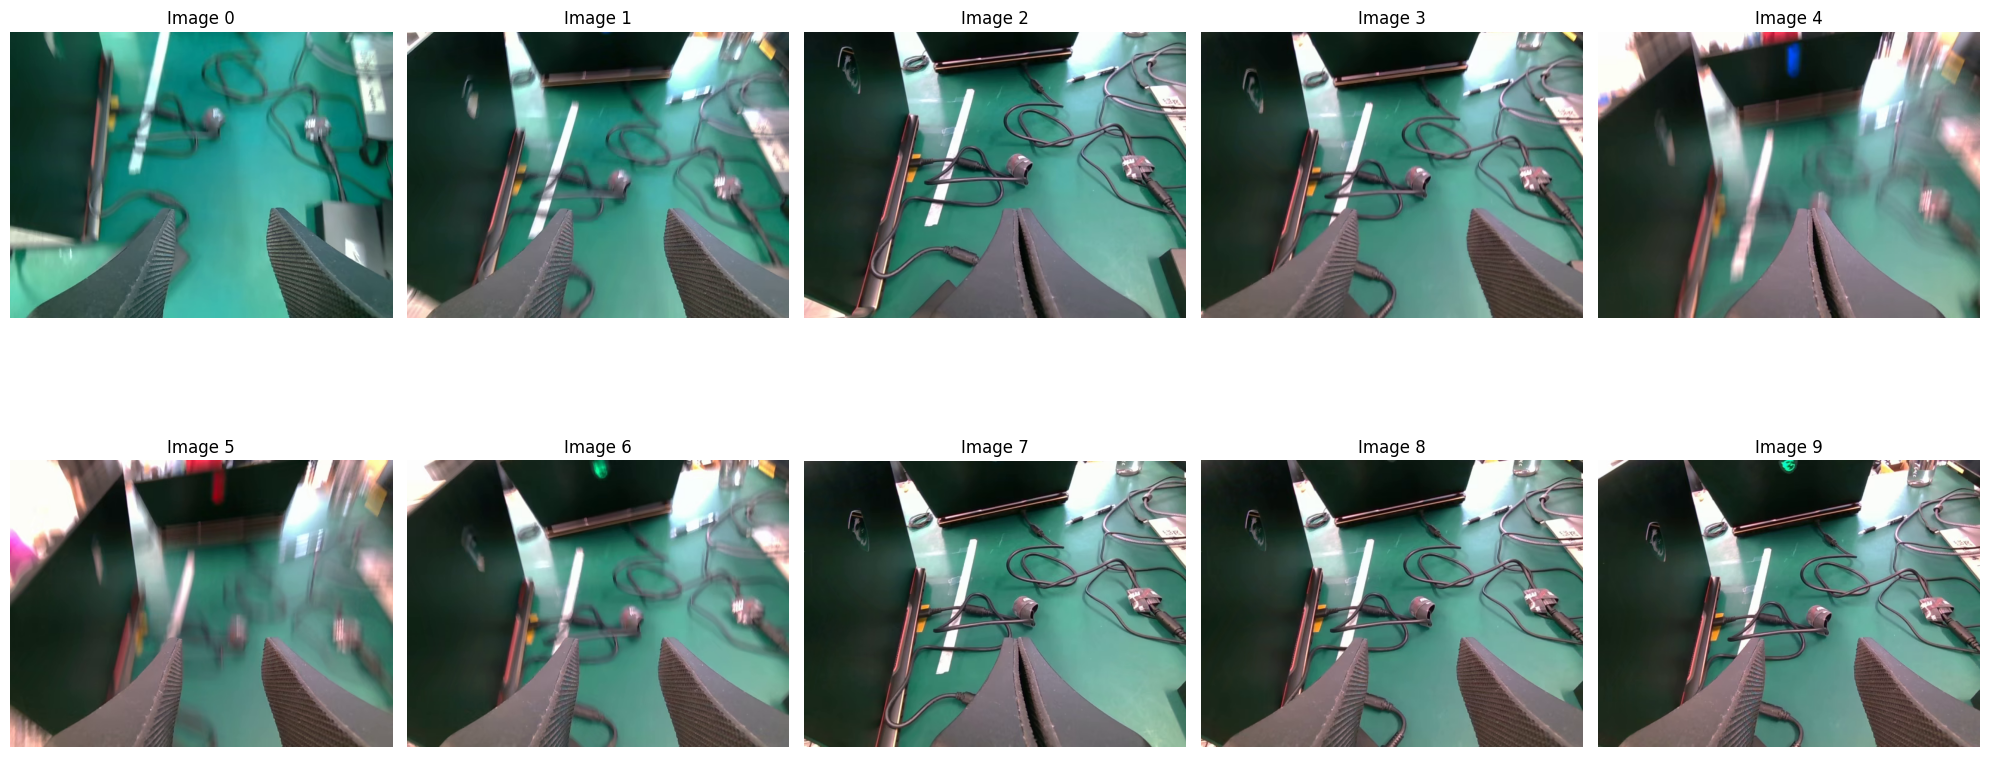

In [10]:
# show img
import matplotlib.pyplot as plt

images_list = []

for i in range(100):
    if i % 10 == 0:
        resp = dataset[i]
        img = resp["video.cam_1"][0]
        images_list.append(img)


fig, axs = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axs.flat):
    ax.imshow(images_list[i])
    ax.axis("off")
    ax.set_title(f"Image {i}")
plt.tight_layout() # adjust the subplots to fit into the figure area.
plt.show()


## Transforming the data

We can also apply a series of transformation to the data to our `LeRobotSingleDataset` class. This shows how to apply transformations to the data.

In [11]:
from gr00t.data.transform.base import ComposedModalityTransform
from gr00t.data.transform import VideoToTensor, VideoCrop, VideoResize, VideoColorJitter, VideoToNumpy
from gr00t.data.transform.state_action import StateActionToTensor, StateActionTransform
from gr00t.data.transform.concat import ConcatTransform


video_modality = modality_configs["video"]
state_modality = modality_configs["state"]
action_modality = modality_configs["action"]

# select the transforms you want to apply to the data
to_apply_transforms = ComposedModalityTransform(
    transforms=[
        # video transforms
        VideoToTensor(apply_to=video_modality.modality_keys),
        VideoCrop(apply_to=video_modality.modality_keys, scale=0.95),
        VideoResize(apply_to=video_modality.modality_keys, height=224, width=224, interpolation="linear"),
        VideoColorJitter(apply_to=video_modality.modality_keys, brightness=0.3, contrast=0.4, saturation=0.5, hue=0.08),
        VideoToNumpy(apply_to=video_modality.modality_keys),

        # state transforms
        StateActionToTensor(apply_to=state_modality.modality_keys),
        StateActionTransform(apply_to=state_modality.modality_keys, normalization_modes={
            key: "min_max" for key in state_modality.modality_keys
        }),

        # action transforms
        StateActionToTensor(apply_to=action_modality.modality_keys),
        StateActionTransform(apply_to=action_modality.modality_keys, normalization_modes={
            key: "min_max" for key in action_modality.modality_keys
        }),

        # ConcatTransform
        ConcatTransform(
            video_concat_order=video_modality.modality_keys,
            state_concat_order=state_modality.modality_keys,
            action_concat_order=action_modality.modality_keys,
        ),
    ]
)

Now see how the data is different after applying the transformations.

e.g. states and actions are being normalized and concatenated, video images are being cropped, resized, and color-jittered.

In [13]:
dataset = LeRobotSingleDataset(
    DATA_PATH,
    modality_configs,
    transforms=to_apply_transforms,
    embodiment_tag=embodiment_tag,
    video_backend="torchvision_av"
)

# print the 7th data point
resp = dataset[7]
any_describe(resp)
print(resp.keys())


Initialized dataset piper_test with EmbodimentTag.NEW_EMBODIMENT
{'action': 'torch: [16, 7] torch.float64 cpu',
 'annotation.human.task_description': ['My task description'],
 'state': 'torch: [1, 7] torch.float64 cpu',
 'video': 'np: [1, 1, 224, 224, 3] uint8'}
dict_keys(['annotation.human.task_description', 'video', 'state', 'action'])
